# Advance EDA & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.shape

Rows : 1200
Columns : 14


(1200, 14)

In [4]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 226.8 KB


In [6]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [7]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
for col in df.columns:
    print(col, ":", df[col].nunique())

OrderID : 1200
Date : 671
CustomerID : 1189
Product : 7
Quantity : 5
UnitPrice : 1193
ShippingAddress : 655
PaymentMethod : 5
OrderStatus : 5
TrackingNumber : 1200
ItemsInCart : 10
CouponCode : 3
ReferralSource : 5
TotalPrice : 1195


In [10]:
df.dtypes

OrderID                str
Date                   str
CustomerID             str
Product                str
Quantity             int64
UnitPrice          float64
ShippingAddress        str
PaymentMethod          str
OrderStatus            str
TrackingNumber         str
ItemsInCart          int64
CouponCode             str
ReferralSource         str
TotalPrice         float64
dtype: object

In [11]:
df_clean = df.copy()

df_clean.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [13]:
missing = df_clean.isnull().sum()
missing

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

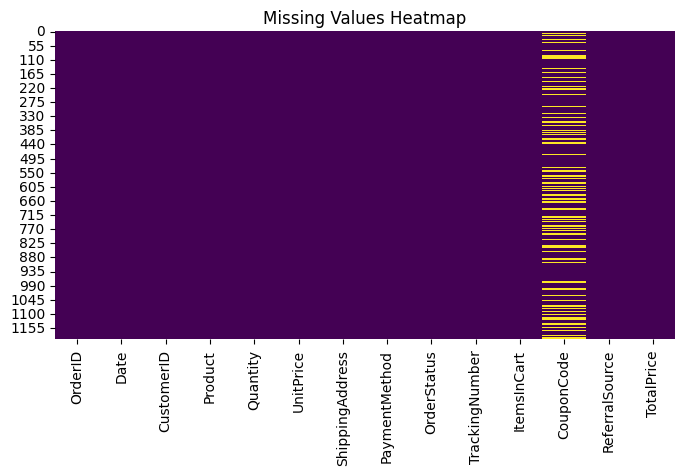

In [16]:
plt.figure(figsize=(8,4))

sns.heatmap(df_clean.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

In [17]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"])

In [18]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [19]:
df_clean["Year"] = df_clean["Date"].dt.year

df_clean["Month"] = df_clean["Date"].dt.month_name()

df_clean["Day"] = df_clean["Date"].dt.day

df_clean["Weekday"] = df_clean["Date"].dt.day_name()

In [20]:
df_clean.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,Weekday
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,January,4,Wednesday
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,August,23,Friday
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,February,27,Tuesday
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,October,15,Sunday
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,May,8,Thursday


In [21]:
print("Shape :", df_clean.shape)

print("\nMissing Values\n")

print(df_clean.isnull().sum())

Shape : (1200, 18)

Missing Values

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
Year                 0
Month                0
Day                  0
Weekday              0
dtype: int64


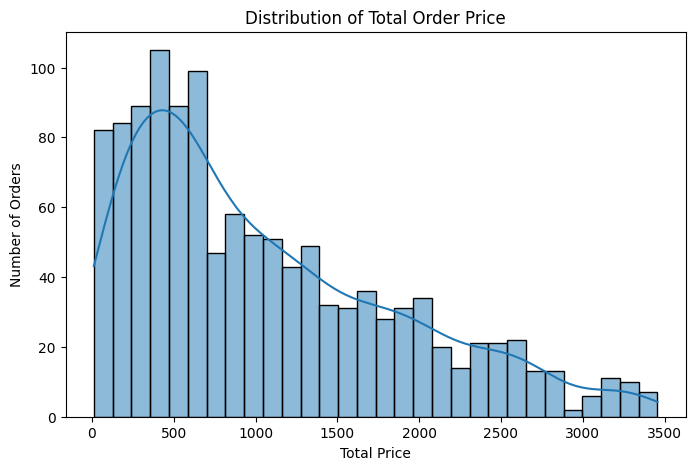

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["TotalPrice"], bins=30, kde=True)

plt.title("Distribution of Total Order Price")
plt.xlabel("Total Price")
plt.ylabel("Number of Orders")

plt.show()

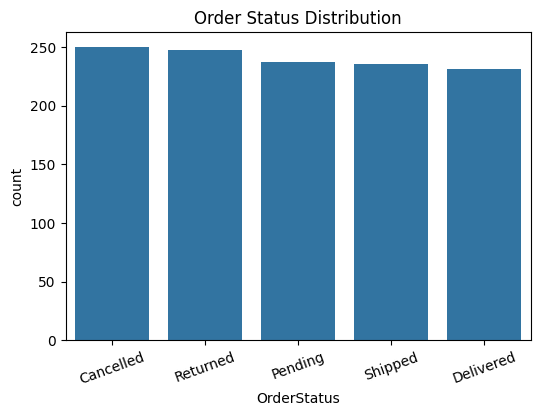

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="OrderStatus",
    data=df_clean,
    order=df_clean["OrderStatus"].value_counts().index
)

plt.title("Order Status Distribution")
plt.xticks(rotation=20)

plt.show()

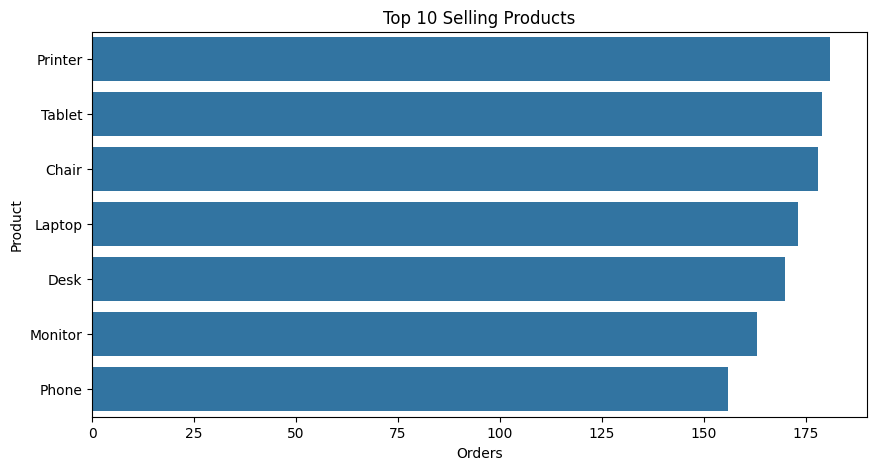

In [24]:
top_products = df_clean["Product"].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Selling Products")
plt.xlabel("Orders")
plt.ylabel("Product")

plt.show()

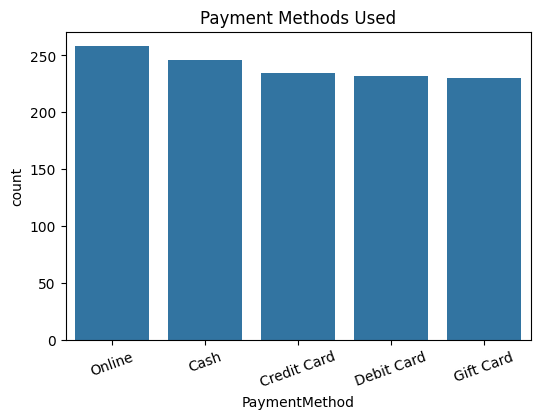

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="PaymentMethod",
    data=df_clean,
    order=df_clean["PaymentMethod"].value_counts().index
)

plt.title("Payment Methods Used")
plt.xticks(rotation=20)

plt.show()

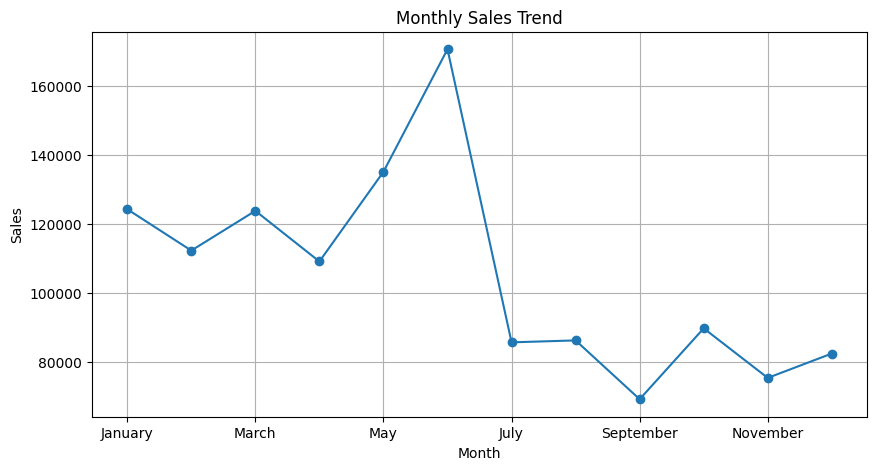

In [26]:
monthly_sales = (
    df_clean.groupby("Month")["TotalPrice"]
    .sum()
    .reindex([
        "January","February","March","April",
        "May","June","July","August",
        "September","October","November","December"
    ])
)

plt.figure(figsize=(10,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

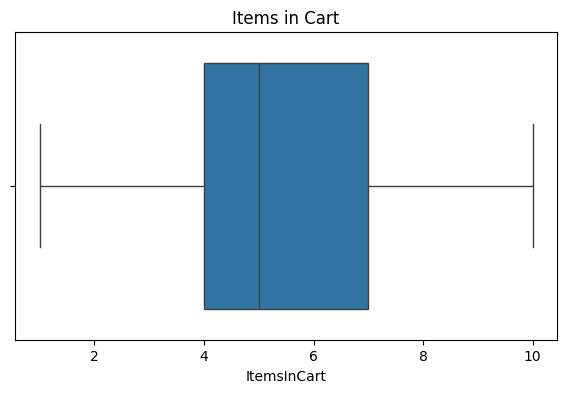

In [27]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df_clean["ItemsInCart"])

plt.title("Items in Cart")

plt.show()

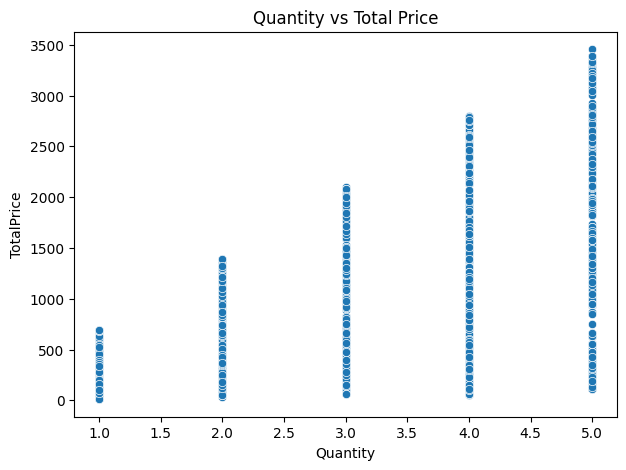

In [28]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Quantity",
    y="TotalPrice",
    data=df_clean
)

plt.title("Quantity vs Total Price")

plt.show()

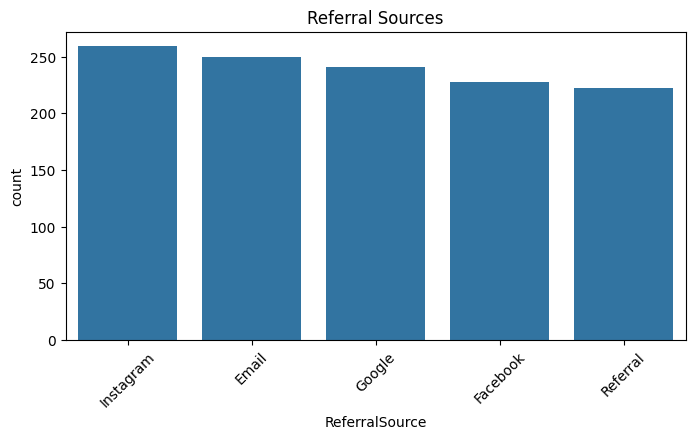

In [29]:
plt.figure(figsize=(8,4))

sns.countplot(
    x="ReferralSource",
    data=df_clean,
    order=df_clean["ReferralSource"].value_counts().index
)

plt.title("Referral Sources")
plt.xticks(rotation=45)

plt.show()

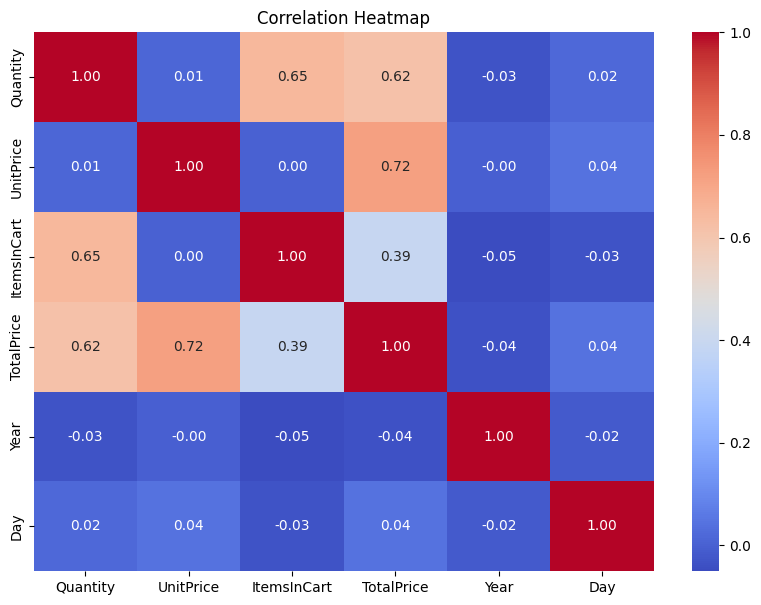

In [30]:
plt.figure(figsize=(10,7))

numeric_df = df_clean.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

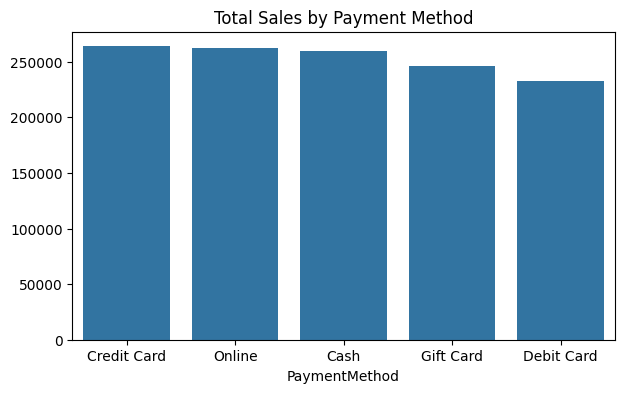

In [31]:
payment_sales = (
    df_clean.groupby("PaymentMethod")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7,4))

sns.barplot(
    x=payment_sales.index,
    y=payment_sales.values
)

plt.title("Total Sales by Payment Method")

plt.show()

In [32]:
df_clean["AveragePricePerItem"] = (
    df_clean["TotalPrice"] / df_clean["Quantity"]
).round(2)

df_clean.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,Weekday,AveragePricePerItem
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,January,4,Wednesday,570.62
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,August,23,Friday,151.35
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,February,27,Tuesday,550.68
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,October,15,Sunday,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,May,8,Thursday,626.01


In [33]:
df_clean["CouponUsed"] = np.where(
    df_clean["CouponCode"].isnull(),
    "No",
    "Yes"
)

df_clean.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,Weekday,AveragePricePerItem,CouponUsed
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2023,January,4,Wednesday,570.62,Yes
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,2024,August,23,Friday,151.35,Yes
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2024,February,27,Tuesday,550.68,Yes
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,2023,October,15,Sunday,273.19,Yes
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2025,May,8,Thursday,626.01,Yes


In [34]:
df_clean["WeekendOrder"] = np.where(
    df_clean["Weekday"].isin(["Saturday","Sunday"]),
    1,
    0
)

df_clean.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,CouponCode,ReferralSource,TotalPrice,Year,Month,Day,Weekday,AveragePricePerItem,CouponUsed,WeekendOrder
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,...,SAVE10,Instagram,2853.10,2023,January,4,Wednesday,570.62,Yes,0
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,...,SAVE10,Referral,302.70,2024,August,23,Friday,151.35,Yes,0
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,...,FREESHIP,Email,2753.40,2024,February,27,Tuesday,550.68,Yes,0
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,...,SAVE10,Facebook,273.19,2023,October,15,Sunday,273.19,Yes,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,...,SAVE10,Email,2504.04,2025,May,8,Thursday,626.01,Yes,0


In [35]:
df_clean.to_csv(
    "cleaned_dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [36]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   OrderID              1200 non-null   str           
 1   Date                 1200 non-null   datetime64[us]
 2   CustomerID           1200 non-null   str           
 3   Product              1200 non-null   str           
 4   Quantity             1200 non-null   int64         
 5   UnitPrice            1200 non-null   float64       
 6   ShippingAddress      1200 non-null   str           
 7   PaymentMethod        1200 non-null   str           
 8   OrderStatus          1200 non-null   str           
 9   TrackingNumber       1200 non-null   str           
 10  ItemsInCart          1200 non-null   int64         
 11  CouponCode           891 non-null    str           
 12  ReferralSource       1200 non-null   str           
 13  TotalPrice           1200 non-null   float64

In [37]:
print("Original Shape :", df.shape)

print("Cleaned Shape :", df_clean.shape)

Original Shape : (1200, 14)
Cleaned Shape : (1200, 21)
